In [1]:
import tensorflow as tf
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt
import numpy as np

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
CHANNELS = 3
EPOCHS = 100
LEARNING_RATE = 1e-4

In [3]:
VALID_CLASSES = [
    'Black Scurf', 'Blackleg', 'Common Scab',
    'Dry Rot', 'Healthy Potatoes', 'Miscellaneous', 'Pink Rot'
]

In [ ]:
import os
os.makedirs('saved_model', exist_ok=True)

dataset = tf.keras.utils.image_dataset_from_directory(
    'dataset',
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    seed=42,
    class_names=VALID_CLASSES
)

Found 451 files belonging to 7 classes.


In [5]:
class_names = dataset.class_names
n_classes   = len(class_names)
print(f"Classes ({n_classes}): {class_names}")
print(f"Total batch: {len(dataset)} × {BATCH_SIZE} = ~{len(dataset)*BATCH_SIZE} gambar")

Classes (7): ['Black Scurf', 'Blackleg', 'Common Scab', 'Dry Rot', 'Healthy Potatoes', 'Miscellaneous', 'Pink Rot']
Total batch: 57 × 8 = ~456 gambar


In [19]:
def split_dataset(ds, train_split=0.8, val_split=0.1):
    size       = len(ds)
    ds         = ds.shuffle(1000, seed=42)
    train_size = int(train_split * size)
    val_size   = int(val_split   * size)
    return (
        ds.take(train_size),
        ds.skip(train_size).take(val_size),
        ds.skip(train_size + val_size)
    )

train_ds, val_ds, test_ds = split_dataset(dataset)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} batches")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Train: 45 | Val: 5 | Test: 7 batches


In [20]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="augmentation")

In [21]:
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(*IMAGE_SIZE, CHANNELS),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(*IMAGE_SIZE, CHANNELS))
x = augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu',
                       kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu',
                       kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name="PotatoDisease_EfficientNetV2B0")
model.summary()

Model: "PotatoDisease_EfficientNetV2B0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 7, 7, 1280)        5919312   
 nal)                                                            
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_2 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                    

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cb1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('../saved_models/phase1/phase1_model.h5', monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=4, min_lr=1e-7, verbose=1),
]

print("\n=== PHASE 1: Training head ===")
h1 = model.fit(train_ds, validation_data=val_ds,
               epochs=EPOCHS, callbacks=cb1, verbose=1)


=== PHASE 1: Training head ===
Epoch 1/100
45/45 [==============================] - ETA: 0s - loss: 3.3665 - accuracy: 0.1746
Epoch 1: val_accuracy improved from -inf to 0.30000, saving model to ../saved_models/phase1\phase1_model.h5
45/45 [==============================] - 14s 175ms/step - loss: 3.3665 - accuracy: 0.1746 - val_loss: 2.4334 - val_accuracy: 0.3000 - lr: 1.0000e-04
Epoch 2/100
45/45 [==============================] - ETA: 0s - loss: 2.9703 - accuracy: 0.2113
Epoch 2: val_accuracy improved from 0.30000 to 0.37500, saving model to ../saved_models/phase1\phase1_model.h5
45/45 [==============================] - 6s 136ms/step - loss: 2.9703 - accuracy: 0.2113 - val_loss: 2.3093 - val_accuracy: 0.3750 - lr: 1.0000e-04
Epoch 3/100
45/45 [==============================] - ETA: 0s - loss: 2.8572 - accuracy: 0.2507
Epoch 3: val_accuracy improved from 0.37500 to 0.42500, saving model to ../saved_models/phase1\phase1_model.h5
45/45 [==============================] - 6s 141ms/step -

In [23]:
print("\n=== PHASE 2: Fine-tuning ===")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE / 20),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cb2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                            restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('../saved_models/final/final_model.h5', monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=5, min_lr=1e-8, verbose=1),
]

h2 = model.fit(train_ds, validation_data=val_ds,
               epochs=50, callbacks=cb2, verbose=1)


=== PHASE 2: Fine-tuning ===
Epoch 1/50
45/45 [==============================] - ETA: 0s - loss: 1.4511 - accuracy: 0.6930
Epoch 1: val_accuracy improved from -inf to 0.75000, saving model to ../saved_models/final\final_model.h5
45/45 [==============================] - 15s 188ms/step - loss: 1.4511 - accuracy: 0.6930 - val_loss: 1.3453 - val_accuracy: 0.7500 - lr: 5.0000e-06
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 1.6169 - accuracy: 0.6366
Epoch 2: val_accuracy did not improve from 0.75000
45/45 [==============================] - 6s 144ms/step - loss: 1.6169 - accuracy: 0.6366 - val_loss: 1.3433 - val_accuracy: 0.7500 - lr: 5.0000e-06
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 1.4884 - accuracy: 0.6789
Epoch 3: val_accuracy did not improve from 0.75000
45/45 [==============================] - 6s 144ms/step - loss: 1.4884 - accuracy: 0.6789 - val_loss: 1.3352 - val_accuracy: 0.7500 - lr: 5.0000e-06
Epoch 4/50
45/45 [=================

In [24]:
print("\n=== TEST SET EVALUATION ===")
loss, acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {acc * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")


=== TEST SET EVALUATION ===
7/7 [==============================] - 1s 98ms/step - loss: 1.2608 - accuracy: 0.7679
Test Accuracy : 76.79%
Test Loss     : 1.2608



Classification Report:
                  precision    recall  f1-score   support

     Black Scurf       1.00      0.80      0.89         5
        Blackleg       0.38      0.50      0.43         6
     Common Scab       0.38      1.00      0.55         3
         Dry Rot       0.67      0.33      0.44         6
Healthy Potatoes       1.00      1.00      1.00        16
   Miscellaneous       1.00      0.76      0.87        17
        Pink Rot       0.50      0.67      0.57         3

        accuracy                           0.77        56
       macro avg       0.70      0.72      0.68        56
    weighted avg       0.84      0.77      0.78        56



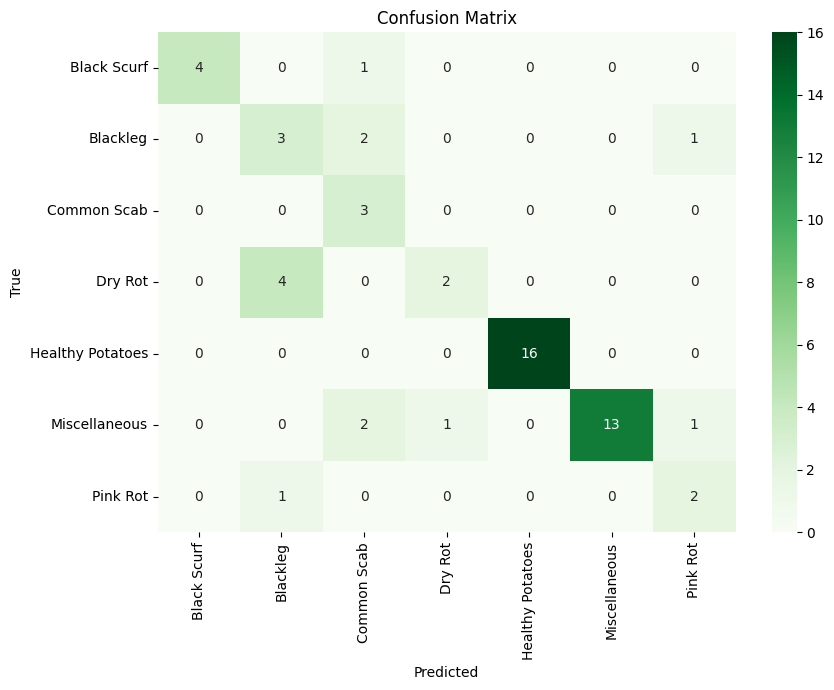

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [26]:
def plot_training_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

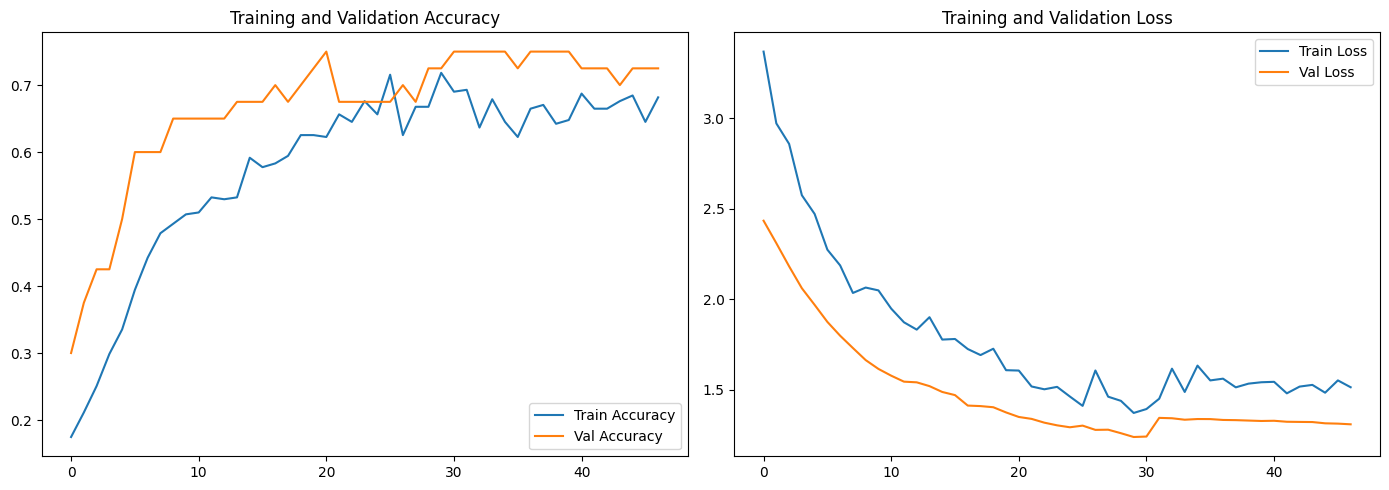

In [27]:
plot_training_history(h1, h2)

In [31]:
def predict_image(img_path, model, class_names):
    img       = tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)        # (1, 224, 224, 3)
    pred      = model.predict(img_array, verbose=0)
    idx       = np.argmax(pred[0])
    print(f"Prediction : {class_names[idx]}")
    print(f"Confidence : {pred[0][idx]*100:.2f}%")
    return class_names[idx], pred[0][idx]

model = tf.keras.models.load_model('../saved_models/final/final_model.h5')
predict_image('testing_data/potato_scab.jpg', model, class_names)

Prediction : Common Scab
Confidence : 76.12%


('Common Scab', 0.76122355)